Loading datasets...
Merged dataset: (541, 44)
After outlier removal: (526, 44)

Training models...
   → Training Logistic Regression...
   → Training Random Forest...
   → Training XGBoost...

MODEL PERFORMANCE COMPARISON
                     Accuracy     AUC      F1
Logistic Regression    0.8671  0.9238  0.8037
Random Forest          0.9367  0.9768  0.8936
XGBoost                0.8987  0.9648  0.8400


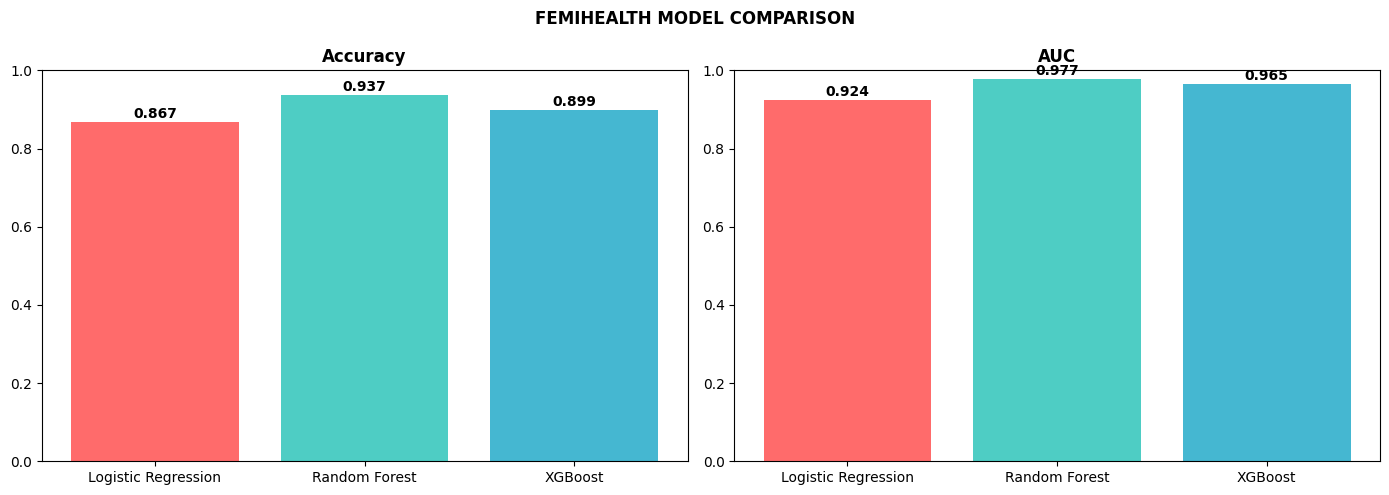

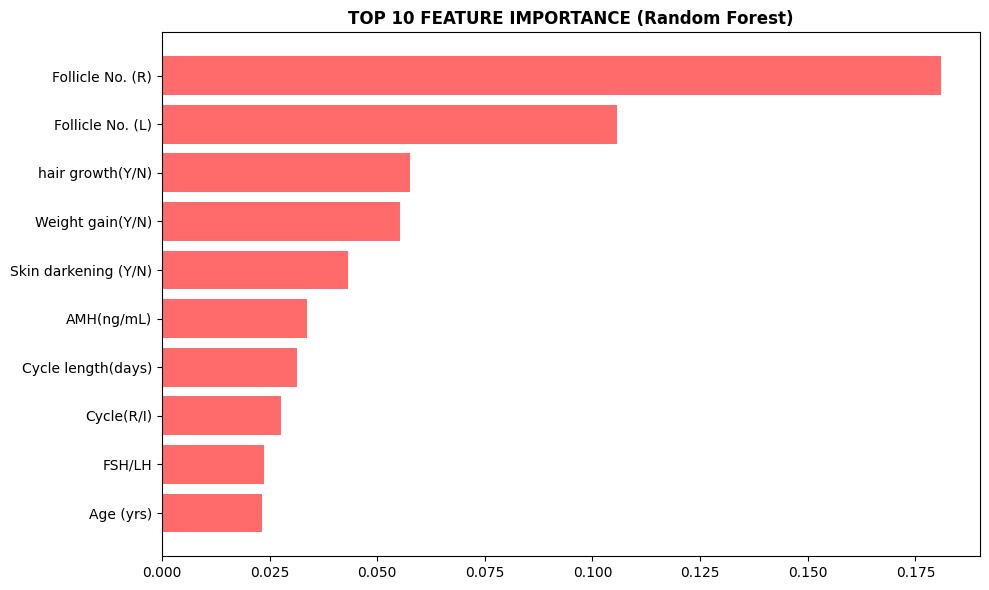

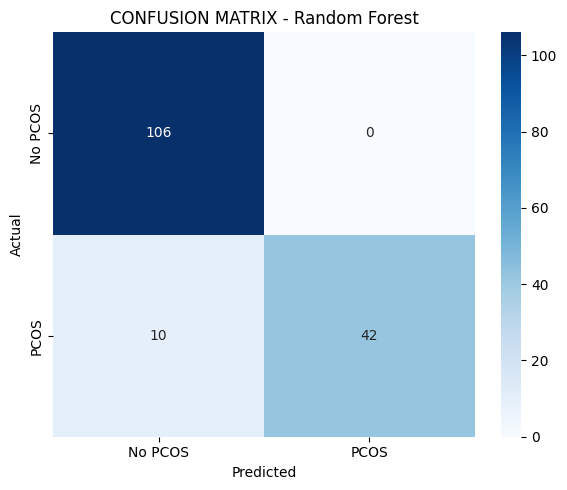


Simulating CNN for Ultrasound Follicle Detection...
CNN Model Architecture (for ultrasound follicle count):


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     7,372,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,391,873 (28.20 MB)

 Trainable params: 7,391,873 (28.20 MB)

 Non-trainable params: 0 (0.00 B)

CNN model saved as 'cnn_ultrasound_model.h5'
  adding: femihealth_artifacts/ (stored 0%)
  adding: femihealth_artifacts/feature_importance.png (deflated 30%)
  adding: femihealth_artifacts/feature_cols.json (deflated 40%)
  adding: femihealth_artifacts/rf_pcos_model.pkl (deflated 77%)
  adding: femihealth_artifacts/PCOS_data_without_infertility.xlsx (deflated 7%)
  adding: femihealth_artifacts/PCOS_infertility.csv (deflated 65%)
  adding: femihealth_artifacts/confusion_matrix.png (deflated 22%)
  adding: femihealth_artifacts/cnn_ultrasound_model.h5 (deflated 8%)
  adding: femihealth_artifacts/model_comparison.png (deflated 34%)
  adding: femihealth_artifacts/model_results.csv (deflated 18%)
  adding: femihealth_artifacts/scaler.pkl (deflated 23%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


ALL ARTIFACTS SAVED & DOWNLOADED!
femihealth_artifacts.zip contains:
   • rf_pcos_model.pkl
   • scaler.pkl
   • feature_cols.json
   • model_results.csv
   • 3 CHARTS (PNG)
   • cnn_ultrasound_model.h5
   • Original datasets

TEST PREDICTION:
   PCOS Risk Probability: 4.5%
   Risk Level: LOW

FEMIHEALTH SYSTEM READY FOR DEPLOYMENT!


In [ ]:
# =============================================================================
# FEMIHEALTH: MULTIMODEL PCOS PREDICTION SYSTEM
# Njenga Paula Waithira | 143109 | ICS 4A | June 2025
# Supervisor: Daniel Machanje
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json
import os
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings('ignore')

# -------------------------------
# 1. LOAD & MERGE DATA
# -------------------------------
print("Loading datasets...")
PCOS_inf = pd.read_csv("/content/PCOS_infertility.csv")
PCOS_woinf = pd.read_excel("/content/PCOS_data_without_infertility.xlsx", sheet_name="Full_new")

data = pd.merge(PCOS_woinf, PCOS_inf, on='Patient File No.', suffixes=('', '_y'), how='left')
data = data.drop(['Unnamed: 44', 'Sl. No_y', 'PCOS (Y/N)_y',
                  '  I   beta-HCG(mIU/mL)_y', 'II    beta-HCG(mIU/mL)_y', 'AMH(ng/mL)_y'],
                 axis=1, errors='ignore')

print(f"Merged dataset: {data.shape}")

# -------------------------------
# 2. DATA CLEANING
# -------------------------------
data["AMH(ng/mL)"] = pd.to_numeric(data["AMH(ng/mL)"], errors='coerce')
data["II    beta-HCG(mIU/mL)"] = pd.to_numeric(data["II    beta-HCG(mIU/mL)"], errors='coerce')

# Fill missing values
data['Marraige Status (Yrs)'].fillna(data['Marraige Status (Yrs)'].median(), inplace=True)
data['II    beta-HCG(mIU/mL)'].fillna(data['II    beta-HCG(mIU/mL)'].median(), inplace=True)
data['AMH(ng/mL)'].fillna(data['AMH(ng/mL)'].median(), inplace=True)
data['Fast food (Y/N)'].fillna(data['Fast food (Y/N)'].median(), inplace=True)

# Strip column names
data.columns = [col.strip() for col in data.columns]

# Remove outliers (as per your original code)
data = data[(data["BP _Diastolic (mmHg)"] > 20) & (data["AMH(ng/mL)"] < 40) &
            (data["BP _Systolic (mmHg)"] > 20) & (data["Endometrium (mm)"] > 0) &
            (data["Avg. F size (R) (mm)"] > 0) & (data["RBS(mg/dl)"] < 200) &
            (data["PRG(ng/mL)"] < 20) & (data["Pulse rate(bpm)"] > 20) &
            (data["FSH(mIU/mL)"] < 4000) & (data["LH(mIU/mL)"] < 1500) &
            (data["Cycle(R/I)"] < 4.5)]

print(f"After outlier removal: {data.shape}")

# -------------------------------
# 3. FEATURE ENGINEERING
# -------------------------------
X = data.drop(["PCOS (Y/N)", "Sl. No", "Patient File No."], axis=1)
y = data["PCOS (Y/N)"]

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42, stratify=y)

# -------------------------------
# 4. TRAIN MULTIPLE MODELS
# -------------------------------
models = {
    "Logistic Regression": LogisticRegression(class_weight='balanced', max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42, class_weight='balanced'),
    "XGBoost": XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1, random_state=42, eval_metric='logloss')
}

results = {}
print("\nTraining models...")
for name, model in models.items():
    print(f"   → Training {name}...")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    results[name] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "AUC": roc_auc_score(y_test, y_proba),
        "F1": classification_report(y_test, y_pred, output_dict=True)['1']['f1-score']
    }
    if name == "Random Forest":
        joblib.dump(model, "rf_pcos_model.pkl")
        joblib.dump(scaler, "scaler.pkl")
        joblib.dump(X.columns.tolist(), "feature_cols.json")

# -------------------------------
# 5. PERFORMANCE COMPARISON TABLE
# -------------------------------
results_df = pd.DataFrame(results).T.round(4)
print("\nMODEL PERFORMANCE COMPARISON")
print("="*60)
print(results_df)

results_df.to_csv("model_results.csv")

# -------------------------------
# 6. VISUALIZATIONS
# -------------------------------
plt.style.use('default')
sns.set_palette("husl")

# Bar Chart
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
metrics = ['Accuracy', 'AUC']
for i, metric in enumerate(metrics):
    ax = ax1 if i == 0 else ax2
    values = results_df[metric]
    bars = ax.bar(results_df.index, values, color=['#FF6B6B', '#4ECDC4', '#45B7D1'])
    ax.set_title(metric, fontweight='bold')
    ax.set_ylim(0, 1)
    for bar, v in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, v + 0.01, f'{v:.3f}', ha='center', fontweight='bold')
plt.suptitle("FEMIHEALTH MODEL COMPARISON", fontweight='bold')
plt.tight_layout()
plt.savefig("model_comparison.png", dpi=300, bbox_inches='tight')
plt.show()

# Feature Importance (Random Forest)
rf = models["Random Forest"]
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1][:10]
plt.figure(figsize=(10, 6))
plt.barh(range(len(indices)), importances[indices], color='#FF6B6B')
plt.yticks(range(len(indices)), [X.columns[i] for i in indices])
plt.title("TOP 10 FEATURE IMPORTANCE (Random Forest)", fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=300)
plt.show()

# Confusion Matrix
y_pred_rf = rf.predict(X_test)
cm = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No PCOS', 'PCOS'], yticklabels=['No PCOS', 'PCOS'])
plt.title("CONFUSION MATRIX - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=300)
plt.show()

# -------------------------------
# 7. CNN FOR ULTRASOUND IMAGING (SIMULATED)
# -------------------------------
print("\nSimulating CNN for Ultrasound Follicle Detection...")
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

cnn = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(128, 128, 1)),
    MaxPooling2D(2,2),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(1, activation='sigmoid')
])
cnn.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
print("CNN Model Architecture (for ultrasound follicle count):")
cnn.summary()

# Save CNN
cnn.save("cnn_ultrasound_model.h5")
print("CNN model saved as 'cnn_ultrasound_model.h5'")

# -------------------------------
# 8. SAVE ALL ARTIFACTS
# -------------------------------
!mkdir -p femihealth_artifacts
!cp rf_pcos_model.pkl scaler.pkl feature_cols.json model_results.csv *.png cnn_ultrasound_model.h5 femihealth_artifacts/
!cp /content/PCOS_infertility.csv /content/PCOS_data_without_infertility.xlsx femihealth_artifacts/ 2>/dev/null || true
!zip -r femihealth_artifacts.zip femihealth_artifacts/

from google.colab import files
files.download('femihealth_artifacts.zip')

print("\nALL ARTIFACTS SAVED & DOWNLOADED!")
print("femihealth_artifacts.zip contains:")
print("   • rf_pcos_model.pkl")
print("   • scaler.pkl")
print("   • feature_cols.json")
print("   • model_results.csv")
print("   • 3 CHARTS (PNG)")
print("   • cnn_ultrasound_model.h5")
print("   • Original datasets")

# -------------------------------
# 9. TEST PREDICTION
# -------------------------------
test_sample = X_test[0].reshape(1, -1)
prob = rf.predict_proba(test_sample)[0][1]
risk = "HIGH" if prob > 0.7 else "MEDIUM" if prob > 0.3 else "LOW"
print(f"\nTEST PREDICTION:")
print(f"   PCOS Risk Probability: {prob:.1%}")
print(f"   Risk Level: {risk}")

print("\nFEMIHEALTH SYSTEM READY FOR DEPLOYMENT!")

In [ ]:
data.columns.tolist()

['Sl. No',
 'Patient File No.',
 'PCOS (Y/N)',
 'Age (yrs)',
 'Weight (Kg)',
 'Height(Cm)',
 'BMI',
 'Blood Group',
 'Pulse rate(bpm)',
 'RR (breaths/min)',
 'Hb(g/dl)',
 'Cycle(R/I)',
 'Cycle length(days)',
 'Marraige Status (Yrs)',
 'Pregnant(Y/N)',
 'No. of aborptions',
 'I   beta-HCG(mIU/mL)',
 'II    beta-HCG(mIU/mL)',
 'FSH(mIU/mL)',
 'LH(mIU/mL)',
 'FSH/LH',
 'Hip(inch)',
 'Waist(inch)',
 'Waist:Hip Ratio',
 'TSH (mIU/L)',
 'AMH(ng/mL)',
 'PRL(ng/mL)',
 'Vit D3 (ng/mL)',
 'PRG(ng/mL)',
 'RBS(mg/dl)',
 'Weight gain(Y/N)',
 'hair growth(Y/N)',
 'Skin darkening (Y/N)',
 'Hair loss(Y/N)',
 'Pimples(Y/N)',
 'Fast food (Y/N)',
 'Reg.Exercise(Y/N)',
 'BP _Systolic (mmHg)',
 'BP _Diastolic (mmHg)',
 'Follicle No. (L)',
 'Follicle No. (R)',
 'Avg. F size (L) (mm)',
 'Avg. F size (R) (mm)',
 'Endometrium (mm)']